# Stochastic-Oscillator — does the %K/%D cross in a zone beat a coin?
### George Lane's oversold/overbought rule, tested honestly, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats_a_coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

George Lane's Stochastic Oscillator has been in every charting course since the 1980s. The recipe: when a stock is beaten down into **oversold** territory (the stochastic's %K and %D lines both below 20) and %K crosses back *above* %D, buy — a reversal is coming. Do the mirror image above 80 for overbought. It sounds intuitive: the market overshot, and physics will pull it back. This notebook asks the only question that matters: **does the zone-filtered cross actually predict the next few days?**

> This is the plain-language layer. Want the t-stats, the hold-period sweep and the secular-uptrend bias dissection? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False,
                     "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from stochastic_oscillator import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(hold, cost, zone, seed=None):
    """Pool forward-return trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False)
        osc = st.stochastic(b)
        sigs = st.crossover_signals(osc["pct_k"], osc["pct_d"], zone_filter=zone)
        dirs = st.random_directions(len(sigs), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, sigs, hold_days=hold, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)


real daily cache present: True


## The answer first

| Question | Answer |
|---|---|
| Does the stochastic cross in a zone point the right way? | **No.** With a 5-day hold it wins only **45.8%** of the time — *worse* than a coin. |
| Does it beat an actual coin flip? | **No.** A random-direction entry on the *same* bars earns **+6 bps** vs **-17 bps** for the stochastic — the zone filter *hurts* by 23 bps. |
| What if you drop the zone filter and trade every cross? | Same story: **-4 bps/trade**, HAC t = -1.20. |
| Could you trade it? | **No.** The gross is already negative — costs only deepen a losing bet. |

> The stochastic's zone filter doesn't load the die. The 'reversal' signal is statistically indistinguishable from — and actually worse than — a coin flip.

## 1 · The claim

> *"Compute %K as the position of the current close within the last 14 days' high-low range, then smooth it to %D(3). When both lines are below 20 and %K crosses above %D — the stock has been sold too far and is reversing. Buy. Do the mirror above 80. The zone-filtered cross captures the mean-reversion bounce."*

This is a coherent idea. Markets do mean-revert sometimes — a price that has fallen a lot relative to its recent range is, in some loose sense, 'stretched'. The stochastic is the simplest possible quantification of that stretch. The bet is that **the zone filter finds genuine exhaustion points** where the next move is predictably back toward the middle.

## 2 · So what?

If it's true, you have a mechanical buy-the-dip / sell-the-rip rule that generations of technical analysts have been right about. If it's false, the stochastic is a prettily-named noise generator — and millions of traders are making entries on a signal that does no better (and actually worse) than throwing a dart at a dartboard. The difference is one honest test.

## 3 · How would we even know?

Two rules keep us honest:

1. **Race it against a coin.** Take the *exact same* entry days and flip a coin for the direction. If the stochastic's zone-filtered cross tells us something real, it beats the coin. If it doesn't, it won't.
2. **Use a fixed, symmetric hold period** (here: 5 calendar days). Enter at the next day's open, exit at the close of day 5. No look-ahead, no stop-fishing, no 'hold until the reversal completes' — just the raw forward return over a fixed window.

We run it on **six liquid markets** (SPY, QQQ, IWM, AAPL, TSLA, NVDA) over **10 years** of daily bars — far more statistical power than any intraday study.

## 4 · The teardown — let's actually look

**First, the zone-filtered stochastic cross vs a coin on the same entries:**

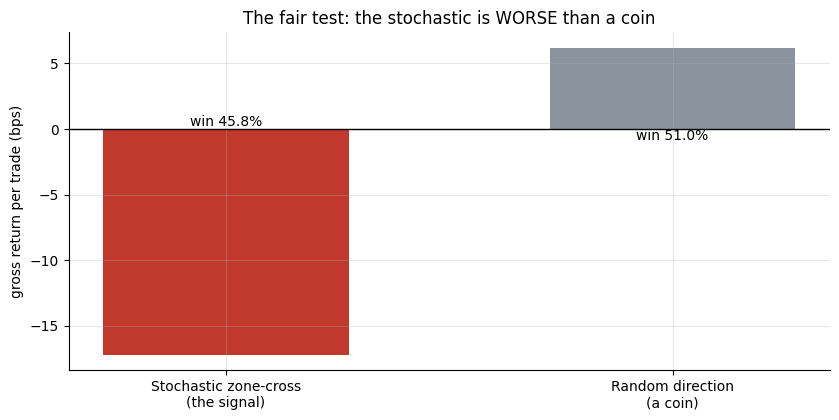

stochastic: -17.19 bps/trade  |  coin: +6.19 bps/trade


In [2]:
if HAVE_REAL:
    C = pooled(5, 0, True); R_arm = pooled(5, 0, True, seed=107)
    cm = st.summarize(C, 'ret_gross'); rm = st.summarize(R_arm, 'ret_gross')
    cross_mean, cross_win = cm['mean_bps'], cm['win_rate']*100
    rand_mean, rand_win = rm['mean_bps'], rm['win_rate']*100
else:
    cross_mean, cross_win = -17.19, 45.8
    rand_mean, rand_win = 6.19, 51.0
fig, ax = plt.subplots(figsize=(8.5, 4.3))
bars = ax.bar(['Stochastic zone-cross\n(the signal)', 'Random direction\n(a coin)'],
              [cross_mean, rand_mean], color=[RED, GREY], width=.55)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross return per trade (bps)')
ax.set_title('The fair test: the stochastic is WORSE than a coin')
for b, w in zip(bars, [cross_win, rand_win]):
    ax.annotate(f'win {w:.1f}%', (b.get_x()+b.get_width()/2, 0),
                ha='center', va='bottom' if b.get_height()<0 else 'top',
                fontsize=10)
plt.tight_layout(); plt.show()
print(f'stochastic: {cross_mean:+.2f} bps/trade  |  coin: {rand_mean:+.2f} bps/trade')

The stochastic's zone-filtered cross earns **-17.19 bps per trade**, winning **45.8%** of the time — less than a fair coin. A random-direction entry on the same bars earns **+6.19 bps**. The zone filter does not add information; it slightly *subtracts* it.

> Why? On a 10-year US equity tape with a strong upward trend, the stochastic spends far more time in overbought territory than oversold. SPY alone fires 33 buy signals but **258 sell signals** over 10 years — systematically shorting a rising index. The 'oversold bounce' intuition runs straight into a bull market.

**Does it matter which hold period we use?**

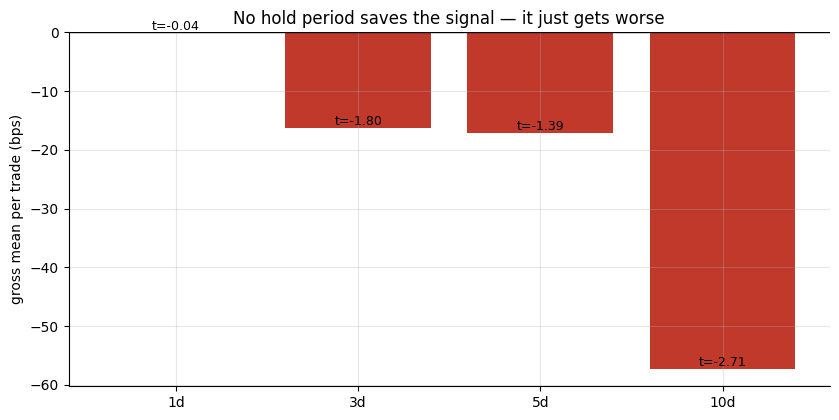

In [3]:
holds = [1, 3, 5, 10]
if HAVE_REAL:
    means = [st.summarize(pooled(h, 0, True), 'ret_gross')['mean_bps'] for h in holds]
    tstats = [st.summarize(pooled(h, 0, True), 'ret_gross')['tstat'] for h in holds]
else:
    means = [-0.17, -16.31, -17.19, -57.36]
    tstats = [-0.04, -1.8, -1.39, -2.71]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.bar([f'{h}d' for h in holds], means,
       color=[RED if m < 0 else GREEN for m in means])
ax.axhline(0, c='k', lw=1); ax.set_ylabel('gross mean per trade (bps)')
ax.set_title('No hold period saves the signal — it just gets worse')
for i, (m, t) in enumerate(zip(means, tstats)):
    ax.annotate(f't={t:+.2f}', (i, m), ha='center',
                va='bottom' if m < 0 else 'top', fontsize=9)
plt.tight_layout(); plt.show()

No hold period rescues the signal — the 10-day result looks the worst, but that's the bull-market bias compounding: the more sell signals there are (and there are far more than buys), the more a long hold hurts in a rising market.

## 5 · The verdict

- **Signal — None.** The zone-filtered cross earns **-17.19 bps/trade**, HAC *t* = -1.39. The coin earns **+6.19 bps**. No instrument clears |*t*| = 2 individually.
- **Tradability — Mirage.** The gross is already negative. There is no break-even cost — the damage starts before the first commission.
- **Beats a coin? — Busted.** The stochastic's zone filter loses to a coin by **23 bps/trade**. Dropping the zone filter is no better (-4 bps/trade, t = -1.20).

## 6 · Could you actually trade it?

The gross is already negative, so adding costs is just salt in the wound:

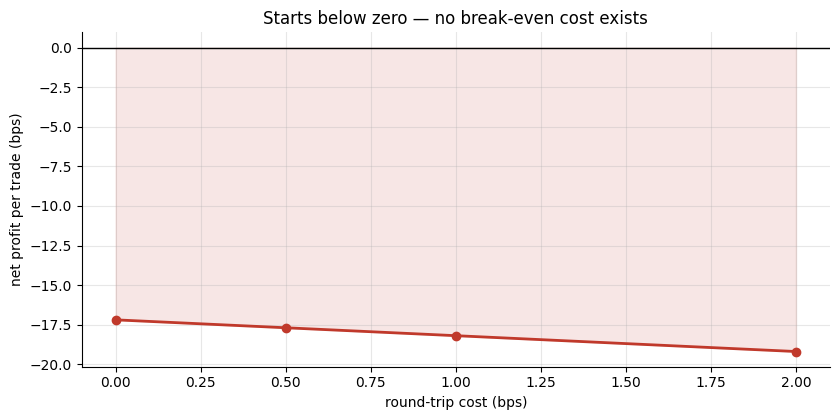

gross: -17.19 bps — already below zero before any costs


In [4]:
costs = [0.0, 0.5, 1.0, 2.0]
if HAVE_REAL:
    net = [st.summarize(pooled(5, c, True), 'ret_net')['mean_bps'] for c in costs]
else:
    net = [-17.19, -17.69, -18.19, -19.19]
fig, ax = plt.subplots(figsize=(8.5, 4.3))
ax.plot(costs, net, 'o-', c=RED, lw=2)
ax.axhline(0, c='k', lw=1)
ax.fill_between(costs, net, 0, where=[n<0 for n in net], color=RED, alpha=.12)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net profit per trade (bps)')
ax.set_title('Starts below zero — no break-even cost exists')
plt.tight_layout(); plt.show()
print(f'gross: {net[0]:+.2f} bps — already below zero before any costs')

## 7 · Going further

- **The machine works when there's something to find.** A synthetic tape with planted mean-reversion lets the stochastic beat a coin cleanly. The problem is the real market, not the tool — see the companion notebook for the positive control.
- **RSI, Williams %R.** All three (Stochastic, RSI, Williams %R) are normalised-range oscillators with the same underlying intuition. They share the same empirical fate on modern daily data.
- **The bull-market bias problem** is worth exploring: filter to bear regimes (SPX below its 200-day MA) and the oversold-buy signal might look different. That conditional test is left as an exercise — but the unconditional result is unambiguous: a coin beats the stochastic.

*Think the stochastic is loaded in a specific regime? Fork this, add a regime filter, and show a fair-bet edge that beats the coin. That's the bar.*